# understanding some code logic

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch

%matplotlib inline
torch.manual_seed(555)
np.random.seed(555)

# Starndard Markovian diffusion

In [65]:
from data.generate_data import generate_ordinary_diffusion

x, t, c = generate_ordinary_diffusion(D = 0.01, Nx = 51, Nt = 101, L=1, T=2, x0=0.5, sigma=0.05)

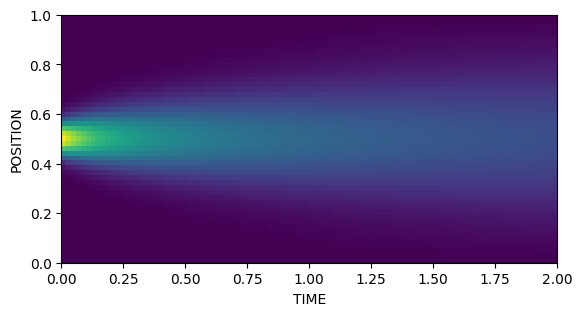

In [66]:
X, T = np.meshgrid(x,t)
plt.imshow(c, extent=[t.min(), t.max(), x.min(), x.max()])
plt.xlabel("TIME")
plt.ylabel("POSITION")
plt.show()

# Non-Markovian diffusion

In [78]:
from data.generate_data import generate_memory_diffusion

exp_ker = lambda x : np.exp(-x)
pow_law = lambda x : 1/(x+1)

x, t, c = generate_memory_diffusion(pow_law,
                                    D = 0.1,
                                    Nx = 51,
                                    Nt = 101,
                                    L = 1.0,
                                    x0 = 0.5, 
                                    sigma = 0.05 )



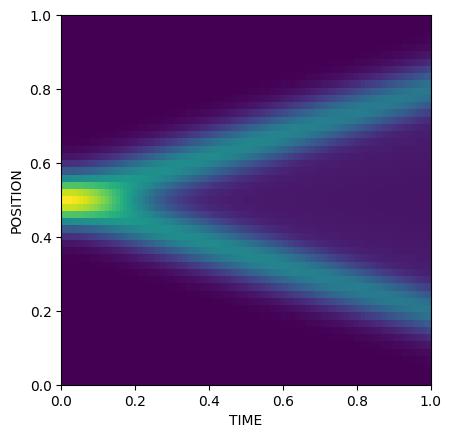

In [80]:
X, T = np.meshgrid(x,t)
plt.imshow(c, extent=[t.min(), t.max(), x.min(), x.max()])
plt.xlabel("TIME")
plt.ylabel("POSITION")
plt.show()

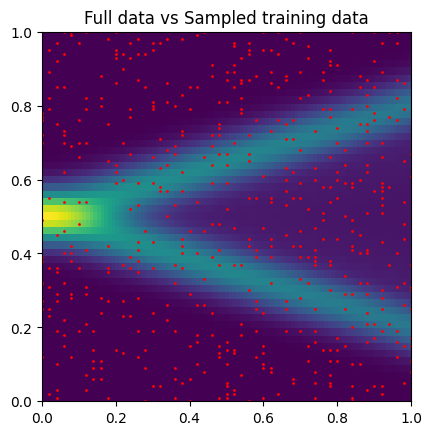

In [82]:
from data.generate_data import subsample_observations
xo, to, co = subsample_observations(x, t, c,0.1,)
plt.imshow(c, extent=[t.min(), t.max(), x.min(), x.max()])
plt.plot(xo, to, "ro", markersize=1)
plt.title("Full data vs Sampled training data")
plt.show()

# understanding torch grads

In [ ]:

# simple example for grad

x = torch.tensor(2.0, requires_grad=True)
y = torch.exp(x**2)
y.backward()
print("x =", x.item())
print("y =", y.item())
print("Torch dy/dx =", x.grad.item())
print("Exact dy/dx =", (2 * x * torch.exp(x**2)).item())


x = torch.tensor(2.0, requires_grad=True)
y = torch.exp(x**2)

dy_dx = torch.autograd.grad(y, x)
print(dy_dx[0].item())


x = 2.0
y = 54.598148345947266
Torch dy/dx = 218.39259338378906
Exact dy/dx = 218.39259338378906
218.39259338378906


(tensor(218.3926),)


## Now data generation is complete

# Train the baseline model without any memory